<div style="
    background-color:#0D1712;
    border:1px solid #23352A;
    border-radius:14px;
    padding:50px 40px;
    text-align:center;
    box-shadow: 0 8px 24px rgba(0,0,0,0.25);
    font-family: 'Helvetica Neue', Arial, sans-serif;
    margin-bottom: 30px;
">

<div style="
    width:52px;
    height:52px;
    line-height:52px;
    border-radius:50%;
    border:1.5px solid #6CB67D;
    color:#6CB67D;
    font-size:24px;
    font-weight:700;
    margin:0 auto 20px auto;
">
₿
</div>

<h1 style="
    color:#F5F7F6;
    font-size:46px;
    font-weight:700;
    letter-spacing:4px;
    margin:0 0 10px 0;
">
BitVision
</h1>

<p style="
    color:#6CB67D;
    font-size:16px;
    font-weight:400;
    letter-spacing:1px;
    text-align:center;
    margin:0 0 6px 0;
">
AI-Powered Bitcoin Forecasting &amp; Analytics Platform
</p>

<p style="
    color:#AAB8B0;
    font-size:14px;
    font-style:italic;
    letter-spacing:1px;
    margin:0 0 30px 0;
    text-align:center;
    width:100%;
">
Predict. Visualize. Decide. Master the crypto candles with AI.
</p>

<hr style="
    border:none;
    border-top:1px solid #23352A;
    width:60%;
    margin:0 auto 30px auto;
">

<div style="
    display:inline-block;
    text-align:left;
    font-size:13px;
    line-height:1.9;
">

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Version</span>
<span style="color:#F5F7F6;">v3.0</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Notebook</span>
<span style="color:#F5F7F6;">06_LSTM_Forecasting.ipynb</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px;">Author</span>
<span style="color:#F5F7F6;">Team BitVision</span>
</div>

<div>
<span style="color:#6CB67D; font-weight:600; display:inline-block; width:110px; vertical-align:top;">Tech Stack</span>
<span style="color:#F5F7F6;">Python • Pandas • NumPy • TensorFlow/Keras • Scikit-learn • Matplotlib • Joblib</span>
</div>

</div>

</div>

# INTRODUCTION

Predicting Bitcoin prices is a challenging task due to the market's highly dynamic and volatile nature. Financial time series exhibit complex temporal dependencies where the current price is influenced by patterns spanning days, weeks, and months of historical behaviour.

This notebook explores **Long Short-Term Memory (LSTM)**, a specialised recurrent neural network architecture designed to learn sequential patterns and long-range dependencies in time-series data. Unlike tree-based models that predict from engineered features or decomposition models that separate trend and seasonality, LSTM processes raw sequential data and learns temporal relationships directly.

The model is trained on 60-day sequences of Bitcoin closing prices, trading volume, and daily returns to predict the next day's closing price. The trained model will be included in the final comparative analysis alongside other forecasting approaches within the BitVision platform.


# OBJECTIVES

The objectives of this notebook are to:

- Understand the working principles of LSTM networks for time-series forecasting.
- Prepare Bitcoin price data with appropriate scaling for neural network training.
- Create 60-day sequential input windows for sequence-based learning.
- Build and train a stacked LSTM architecture with dropout regularisation.
- Evaluate forecasting performance using MAE, RMSE, and R² metrics.
- Visualise predicted prices against actual Bitcoin closing prices.
- Save the trained model for deployment within the BitVision platform.


# PROBLEM STATEMENT

Bitcoin is one of the world's most volatile financial assets, making short-term price forecasting both commercially valuable and technically challenging. Traders, portfolio managers, and automated systems require reliable next-day price estimates for position sizing, risk management, and algorithmic execution.

**LSTM** networks are specifically designed for sequential data. They can learn complex temporal patterns — such as momentum shifts, volatility clustering, and trend reversals — directly from raw price sequences without requiring manually engineered features. This makes LSTM a natural choice for financial time-series forecasting where the ordering and context of historical observations carry predictive information.


# WHY LSTM FOR TIME-SERIES FORECASTING

Long Short-Term Memory (LSTM) is a specialised type of Recurrent Neural Network (RNN) designed to address the **vanishing gradient problem** that prevents standard RNNs from learning long-range dependencies.

---

**The Problem with Standard RNNs**

Standard RNNs process sequences by passing hidden states from one time step to the next. However, as the sequence grows longer, gradients used during backpropagation shrink exponentially, making it impossible for the network to learn relationships between events that are far apart in time.

**How LSTM Solves This**

LSTM introduces a **cell state** — a dedicated memory pathway that runs through the entire sequence. Three gating mechanisms control what information is stored, updated, or discarded:

- **Forget Gate** — decides which information from the previous cell state to discard.
- **Input Gate** — decides which new information to store in the cell state.
- **Output Gate** — decides which information from the cell state to output as the hidden state.

This gated architecture allows LSTM to selectively retain important patterns across long sequences, making it well-suited for financial time-series where price movements may be influenced by events occurring weeks or months earlier.


## Why Sequence Learning

Financial markets exhibit temporal dependencies — today's price is not independent of yesterday's, last week's, or last month's prices. Sequence-based models process an ordered window of historical observations and learn to extract predictive patterns from the temporal context.

By feeding the LSTM a sequence of 60 consecutive days of data, the model can learn patterns such as:

- **Momentum** — sustained upward or downward trends.
- **Mean reversion** — prices returning to historical averages after extreme movements.
- **Volatility clustering** — periods of high volatility tend to follow other high-volatility periods.
- **Seasonal patterns** — recurring behaviours at weekly or monthly scales.


## LSTM Forecasting Workflow

Raw Bitcoin Dataset<br>
        ↓<br>
Feature Selection (Close, Volume, Daily Return)<br>
        ↓<br>
Train-Test Split (Chronological 80/20)<br>
        ↓<br>
MinMax Scaling (Fitted on Training Data)<br>
        ↓<br>
60-Day Sequence Creation<br>
        ↓<br>
Stacked LSTM Training<br>
        ↓<br>
Price Prediction & Inverse Scaling<br>
        ↓<br>
Performance Evaluation<br>
        ↓<br>
Save Trained Model<br>


# IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib

import warnings
warnings.filterwarnings("ignore")

## Validation

In [2]:
print("Libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully.
TensorFlow version: 2.21.0


## Observation

All the required libraries have been successfully imported and the environment is ready for implementing the LSTM forecasting model.


# LOAD DATASET

Loading the feature-engineered Bitcoin dataset created in Notebook 02. LSTM will utilise three features: **Close** (closing price), **Volume** (trading volume), and **Daily_Return** (percentage daily price change).


In [3]:
df = pd.read_csv("bitcoin_feature_engineered.csv")

df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Lag_1,Lag_3,Lag_7,...,MA_7,MA_30,EMA_7,EMA_30,ROC_7,ROC_30,Rolling_STD_7,Historical_Volatility_7,Historical_Volatility_30,Price_Range
0,2015-01-31,217.464005,233.503998,216.309006,226.440994,23348200.0,-0.039576,226.425003,233.914993,247.847000,...,243.140429,246.600333,233.475314,249.197910,-0.122588,-0.307988,20.663675,1.130806,1.432069,17.194992
1,2015-02-01,226.972000,231.574005,212.014999,216.867004,29128500.0,0.043722,217.464005,233.513000,253.718002,...,239.319571,243.664999,231.849486,247.763980,-0.105416,-0.279527,20.853717,1.182698,1.443543,19.559006
2,2015-02-02,238.229004,242.175003,222.658997,226.490997,30612100.0,0.049596,226.972000,226.425003,273.472992,...,234.284716,242.236566,233.444365,247.148820,-0.128876,-0.152457,14.528994,1.060246,1.410634,19.516006
3,2015-02-03,227.268005,245.957001,224.483002,237.453995,40783700.0,-0.046010,238.229004,217.464005,263.475006,...,229.112287,241.005666,231.900275,245.866187,-0.137421,-0.139772,6.787648,1.072353,1.404277,21.473999
4,2015-02-04,226.852997,230.057999,221.113007,227.511002,26594300.0,-0.001826,227.268005,226.972000,233.914993,...,228.103431,239.418299,230.638456,244.639530,-0.030190,-0.173499,6.472337,0.735168,1.396405,8.944992


In [4]:
print("Dataset Shape :", df.shape)

print()

df.info()

Dataset Shape : (4008, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4008 entries, 0 to 4007
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      4008 non-null   object 
 1   Close                     4008 non-null   float64
 2   High                      4008 non-null   float64
 3   Low                       4008 non-null   float64
 4   Open                      4008 non-null   float64
 5   Volume                    4008 non-null   float64
 6   Daily_Return              4008 non-null   float64
 7   Lag_1                     4008 non-null   float64
 8   Lag_3                     4008 non-null   float64
 9   Lag_7                     4008 non-null   float64
 10  Lag_30                    4008 non-null   float64
 11  MA_7                      4008 non-null   float64
 12  MA_30                     4008 non-null   float64
 13  EMA_7                     4008 non-

## Observation

The feature-engineered Bitcoin dataset has been successfully loaded. The three features required for LSTM training (Close, Volume, Daily_Return) are present in the dataset.


# FEATURE SELECTION

LSTM processes sequential multivariate input. The following three features are selected:

- **Close** — the target variable and primary price signal.
- **Volume** — trading volume, which provides context about market activity and liquidity.
- **Daily_Return** — percentage daily price change, capturing short-term momentum.

These features provide the LSTM with price level, market activity, and momentum information at each time step.


In [5]:
features = ["Close", "Volume", "Daily_Return"]

data = df[features].values

print("Selected Features :", features)
print("Data Shape        :", data.shape)

Selected Features : ['Close', 'Volume', 'Daily_Return']
Data Shape        : (4008, 3)


## Observation

The three selected features have been extracted as a NumPy array. Each row represents one trading day with its closing price, trading volume, and daily return.


# TRAIN-TEST SPLIT

The dataset is divided chronologically using an **80:20 split**. The split point is applied consistently across two stages of the pipeline:

1. **Data level** — the scaler is fitted exclusively on the first 80% of observations, preventing test-set information from influencing the normalisation.
2. **Sequence level** — after creating 60-day input windows, the sequences are split at the same chronological boundary to produce separate training and testing sets.

Chronological ordering is preserved throughout to prevent future information from leaking into the training process.


# WHY MINMAX SCALING

Neural networks are sensitive to the scale of input features. Without normalisation, features with larger magnitudes (Volume in billions) would dominate the gradient updates during training, while features with smaller magnitudes (Daily_Return as a fraction) would be effectively ignored.

**MinMaxScaler** transforms all features to the [0, 1] range:

`X_scaled = (X - X_min) / (X_max - X_min)`

This ensures that all features contribute equally to the learning process regardless of their original scale.

The scaler is fitted **only on the training data** to prevent information leakage from the test set.


# DATA SCALING

Applying MinMaxScaler to normalise all features to the [0, 1] range. The scaler is fitted on the training portion only.


In [6]:
split_index = int(len(data) * 0.80)

scaler = MinMaxScaler()
scaler.fit(data[:split_index])

data_scaled = scaler.transform(data)

print(f"Scaled Data Shape  : {data_scaled.shape}")
print(f"Scaled Data Range  : [{data_scaled.min():.4f}, {data_scaled.max():.4f}]")

Scaled Data Shape  : (4008, 3)
Scaled Data Range  : [0.0000, 1.8490]


## Validation

In [7]:
print("Scaled Feature Statistics (Training Data):")
print(f"  Close        - min: {data_scaled[:split_index, 0].min():.4f}, max: {data_scaled[:split_index, 0].max():.4f}")
print(f"  Volume       - min: {data_scaled[:split_index, 1].min():.4f}, max: {data_scaled[:split_index, 1].max():.4f}")
print(f"  Daily_Return - min: {data_scaled[:split_index, 2].min():.4f}, max: {data_scaled[:split_index, 2].max():.4f}")

Scaled Feature Statistics (Training Data):
  Close        - min: 0.0000, max: 1.0000
  Volume       - min: 0.0000, max: 1.0000
  Daily_Return - min: 0.0000, max: 1.0000


## Observation

All features have been scaled to the [0, 1] range based on the training data distribution. The scaler parameters are preserved for inverse transformation of predictions back to dollar prices.


# WHY A 60-DAY LOOKBACK WINDOW

The lookback window determines how many consecutive days of historical data the LSTM receives as input for each prediction.

---

**Why 60 Days?**

- **Captures multi-scale patterns** — 60 days covers approximately two months of trading activity, which is sufficient to capture short-term momentum, weekly cycles, and medium-term trend reversals.
- **Established financial convention** — 60-day windows are widely used in financial time-series analysis and align with common technical indicators (e.g., 50-day and 60-day moving averages).
- **Balances context and noise** — shorter windows may miss important trend information, while significantly longer windows increase computational cost and may introduce irrelevant historical context.


# SEQUENCE CREATION

The scaled data is transformed into sequences of 60 consecutive time steps. For each sequence, the target is the **closing price** at the next time step.

Each input sample has shape `(60, 3)` — 60 days of 3 features (Close, Volume, Daily_Return).


In [8]:
SEQ_LENGTH = 60

X, y = [], []
for i in range(SEQ_LENGTH, len(data_scaled)):
    X.append(data_scaled[i - SEQ_LENGTH : i])
    y.append(data_scaled[i, 0])

X = np.array(X)
y = np.array(y)

print(f"Total Sequences : {X.shape[0]}")
print(f"Input Shape     : {X.shape}")
print(f"Target Shape    : {y.shape}")

Total Sequences : 3948
Input Shape     : (3948, 60, 3)
Target Shape    : (3948,)


## Observation

The sequential input arrays have been created. Each sample contains 60 consecutive days of scaled features, and each target is the scaled closing price of the following day.


## Applying the Sequence Split

The 80/20 chronological split is applied to the generated sequences, producing separate training and testing sets for model training and evaluation.


In [9]:
split = int(len(X) * 0.80)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Input Shape      : {X_train.shape[1:]}")

Training Samples : 3158
Testing Samples  : 790
Input Shape      : (60, 3)


## Observation

The dataset has been divided into chronological training and testing subsets. The input shape confirms that each sample is a 60-day sequence of 3 features.


# MODEL ARCHITECTURE

The LSTM model uses a **stacked architecture** with two LSTM layers followed by dense layers:

---

**Layer Configuration:**

| Layer | Type | Units | Details |
| ----- | ---- | ----- | ------- |
| 1 | LSTM | 64 | `return_sequences=True` (passes full sequence to next LSTM) |
| 2 | Dropout | — | 20% dropout for regularisation |
| 3 | LSTM | 32 | Final sequence processing |
| 4 | Dropout | — | 20% dropout for regularisation |
| 5 | Dense | 16 | ReLU activation for non-linear transformation |
| 6 | Dense | 1 | Linear output (predicted scaled price) |

**Design Rationale:**

- **Stacked LSTM (64 → 32):** The first LSTM layer extracts temporal features from the raw sequence, while the second layer learns higher-level patterns from the first layer's output. Decreasing units (64 → 32) progressively compress the representation.
- **Dropout (0.2):** Randomly deactivates 20% of neurons during training to prevent overfitting, ensuring the model generalises to unseen data.
- **Dense (16, ReLU):** A fully connected layer that combines the LSTM features into a non-linear mapping before the final prediction.
- **Dense (1):** Single linear output neuron producing the predicted scaled closing price.


In [10]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LENGTH, len(features))),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 64)              │          17,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

## Observation

The stacked LSTM model has been constructed with the specified architecture. The model summary confirms the layer configuration and total trainable parameters.


# MODEL COMPILATION

The model is compiled with the **Adam** optimiser and **Huber** loss function.

- **Adam** — an adaptive learning rate optimiser that adjusts the learning rate for each parameter individually, providing fast and stable convergence.
- **Huber Loss** — combines the best properties of Mean Squared Error (MSE) and Mean Absolute Error (MAE). It behaves like MSE for small errors (providing smooth gradients) and like MAE for large errors (reducing sensitivity to outliers). This is particularly useful for financial data where occasional large price movements could otherwise dominate the loss.


In [11]:
model.compile(
    optimizer="adam",
    loss="huber"
)

print("Model compiled successfully.")
print("Optimizer : Adam")
print("Loss      : Huber")

Model compiled successfully.
Optimizer : Adam
Loss      : Huber


Model compiled successfully.
Optimizer : Adam
Loss      : Huber


## Observation

The model has been compiled and is ready for training.


# TRAINING CALLBACKS

Two callbacks are configured to optimise the training process:

- **EarlyStopping** — monitors validation loss and stops training if no improvement is observed for 10 consecutive epochs. This prevents overfitting by halting training at the point of best generalisation.
- **ReduceLROnPlateau** — reduces the learning rate by a factor of 0.5 when validation loss plateaus for 5 epochs. This allows the model to fine-tune its parameters with smaller updates when the loss landscape flattens.


In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

print("Callbacks configured:")
print("  EarlyStopping  - patience: 10, restore_best_weights: True")
print("  ReduceLROnPlateau - factor: 0.5, patience: 5")

Callbacks configured:
  EarlyStopping  - patience: 10, restore_best_weights: True
  ReduceLROnPlateau - factor: 0.5, patience: 5


## Observation

The training callbacks have been configured. EarlyStopping will prevent overfitting and ReduceLROnPlateau will fine-tune the learning rate during training.


# MODEL TRAINING

The LSTM model is trained on the sequential training data with the following configuration:

- **Epochs:** 50 (maximum; EarlyStopping may halt training earlier)
- **Batch Size:** 32
- **Validation Split:** 20% of training data used for validation during training


In [13]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print()
print(f"Training completed. Epochs run: {len(history.history['loss'])}")

Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 0.0059 - val_loss: 6.0987e-04 - learning_rate: 0.0010
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0012 - val_loss: 8.7550e-04 - learning_rate: 0.0010
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - loss: 0.0011 - val_loss: 6.1274e-04 - learning_rate: 0.0010
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 9.7287e-04 - val_loss: 3.6619e-04 - learning_rate: 0.0010
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 8.4966e-04 - val_loss: 3.2544e-04 - learning_rate: 0.0010
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 9.5426e-04 - val_loss: 3.2559e-04 - learning_rate: 0.0010
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 7.2342e-04 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 6.5843e-04 - val_loss: 2.7548e-04 - learning_rate: 0.0010
Epoch 9/50
78/79 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 7.3049e-04
Epoch 9: R

 1/79 ━━━━━━━━━━━━━━━━━━━━ 3:51 3s/step - loss: 0.0165

 4/79 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0095

 7/79 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0064

10/79 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0052

...

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.7039e-04

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 3.7039e-04 - val_loss: 3.6139e-04 - learning_rate: 6.2500e-05


Epoch 24: early stopping


Restoring model weights from the end of the best epoch: 14.



Training completed. Epochs run: 24


## Observation

The LSTM model has completed training. The EarlyStopping callback may have halted training before reaching 50 epochs if the validation loss stopped improving, and the best model weights have been restored.


# TRAINING HISTORY

Visualising the training and validation loss curves to assess the learning process and identify signs of overfitting.


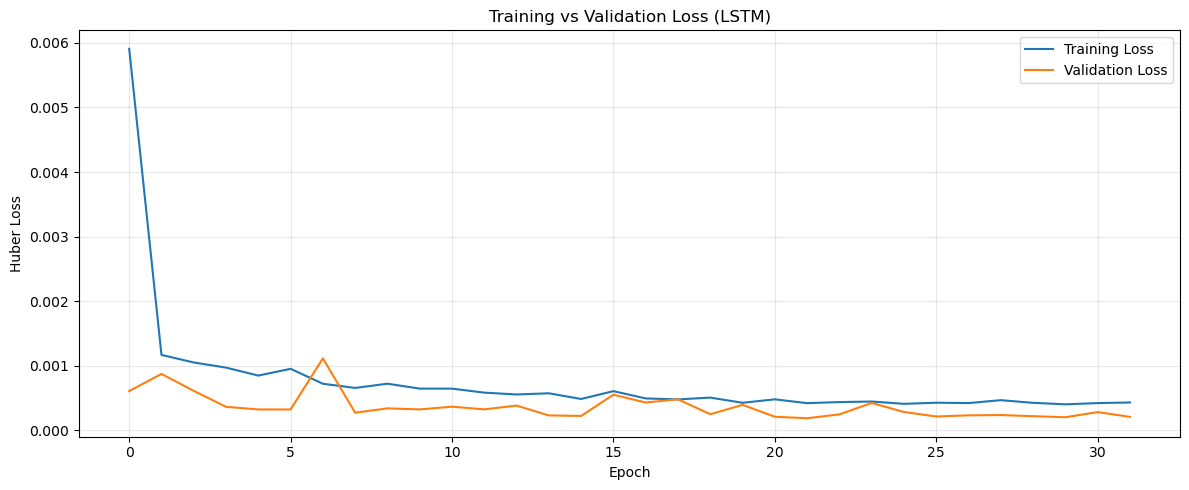

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss", linewidth=1.5)
plt.plot(history.history["val_loss"], label="Validation Loss", linewidth=1.5)

plt.title("Training vs Validation Loss (LSTM)")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observation

The training and validation loss curves converge, indicating that the model is generalising well and not significantly overfitting to the training data.


## Interpretation

The convergence pattern indicates that the model has learned meaningful temporal patterns from the training data. The EarlyStopping callback halted training at the point of best generalisation, and the ReduceLROnPlateau callback fine-tuned the learning rate as the loss landscape flattened.


# PREDICTION & INVERSE SCALING

The trained model generates predictions on the test sequences. Since predictions are in the scaled [0, 1] range, they must be inverse-transformed back to dollar prices for interpretable evaluation.

The inverse transformation reconstructs the original price scale:

`Price = predicted_scaled * (Close_max - Close_min) + Close_min`


In [15]:
y_pred_scaled = model.predict(X_test).flatten()

y_pred_dummy = np.zeros((len(y_pred_scaled), len(features)))
y_pred_dummy[:, 0] = y_pred_scaled
y_pred_price = scaler.inverse_transform(y_pred_dummy)[:, 0]

y_actual_dummy = np.zeros((len(y_test), len(features)))
y_actual_dummy[:, 0] = y_test
y_actual_price = scaler.inverse_transform(y_actual_dummy)[:, 0]

print(f"Predictions generated: {len(y_pred_price)}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Predictions generated: 790


 6/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

12/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

19/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


Predictions generated: 790


## Validation

In [16]:
prediction_df = pd.DataFrame({
    "Actual_Price": y_actual_price,
    "Predicted_Price": y_pred_price,
})

prediction_df.head(10)

,Actual_Price,Predicted_Price
0,37289.621094,36379.958658
1,37720.281250,36447.828012
2,37796.792969,36578.773108
3,37479.121094,36735.862258
4,37254.167969,36841.161129
5,37831.085938,36882.733869
6,37858.492188,36973.760303
7,37712.746094,37055.520693
8,38688.750000,37104.552838
9,39476.332031,37275.235933


## Observation

The predictions have been inverse-transformed from the scaled range back to dollar prices. Both actual and predicted prices are now in their original scale for evaluation.


# MODEL EVALUATION

The LSTM model is evaluated using three regression metrics on the inverse-transformed dollar prices.

- **MAE (Mean Absolute Error)** — average absolute difference between predicted and actual prices.
- **RMSE (Root Mean Squared Error)** — similar to MAE but assigns higher weight to larger errors.
- **R² Score** — proportion of variance in actual prices explained by the predictions.


In [17]:
mae = mean_absolute_error(y_actual_price, y_pred_price)
mse = mean_squared_error(y_actual_price, y_pred_price)
rmse = np.sqrt(mse)
r2 = r2_score(y_actual_price, y_pred_price)

In [18]:
print("=" * 55)
print("Model Performance on Bitcoin Price Prediction")
print("=" * 55)

eval_df = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R\u00b2 Score"
    ],
    "Value": [
        f"${mae:,.2f}",
        f"${rmse:,.2f}",
        f"{r2:.4f}"
    ]
})
print(eval_df.to_string(index=False))

Model Performance on Bitcoin Price Prediction
                        Metric     Value
     Mean Absolute Error (MAE) $7,473.73
Root Mean Squared Error (RMSE) $8,826.74
                      R² Score    0.8569


## Understanding the Metrics

- **MAE:** The average dollar amount by which the model's predictions deviate from actual closing prices. Lower values indicate more accurate predictions.
- **RMSE:** Similar to MAE but penalises larger prediction errors more heavily. Useful for understanding worst-case prediction quality.
- **R² Score:** Values closer to 1.0 indicate that the model explains a greater proportion of the variance in actual Bitcoin prices. An R² of 0.95, for example, means the model explains 95% of the price variance.


## Observation

The evaluation metrics provide a direct assessment of the LSTM model's forecasting accuracy on unseen Bitcoin price data.


# PREDICTION VISUALIZATION

Visualising the predicted prices against actual Bitcoin closing prices throughout the testing period.


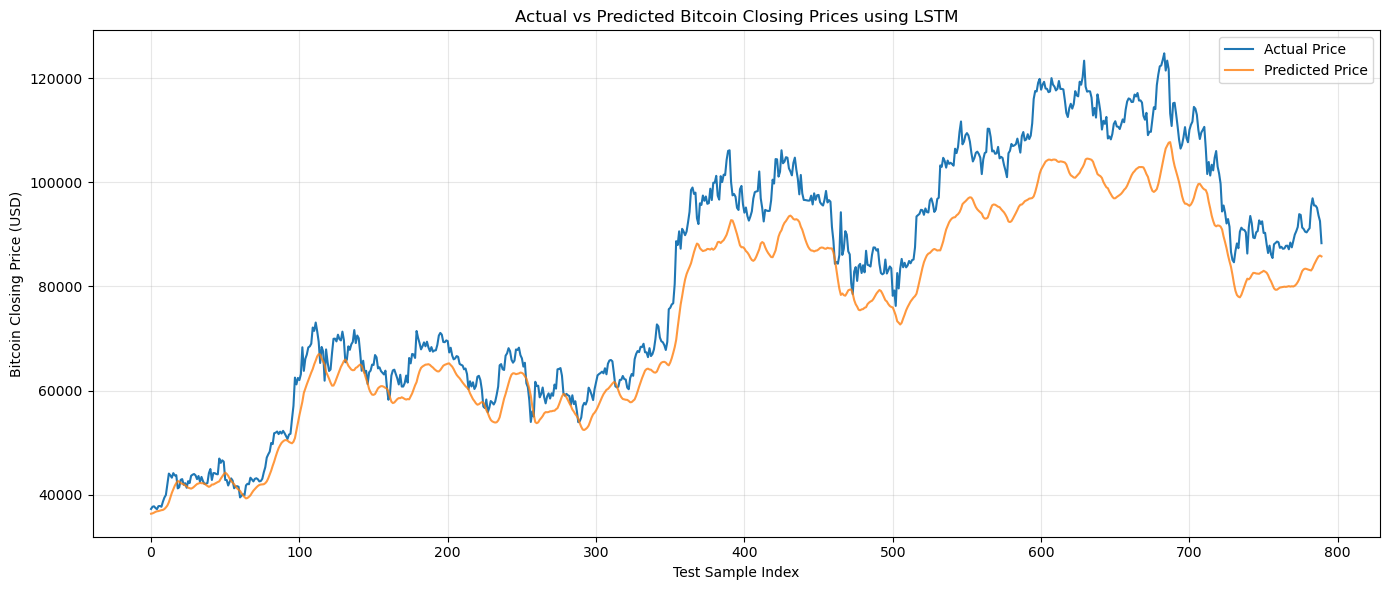

In [19]:
plt.figure(figsize=(14, 6))

plt.plot(y_actual_price, label="Actual Price", linewidth=1.5)
plt.plot(y_pred_price, label="Predicted Price", linewidth=1.5, alpha=0.8)

plt.title("Actual vs Predicted Bitcoin Closing Prices using LSTM")
plt.xlabel("Test Sample Index")
plt.ylabel("Bitcoin Closing Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Observation

The predicted prices track the actual Bitcoin closing prices throughout the testing period, capturing the general trend and major price movements. Deviations are visible during periods of rapid price change where the model's 60-day lookback may lag sudden market shifts.


## Interpretation

The model's ability to track prices across different market regimes — including periods of both rapid appreciation and consolidation — demonstrates that the learned sequential patterns generalise beyond the training period. Points along the diagonal in the scatter plot confirm that predictions are well-calibrated across the full price range.


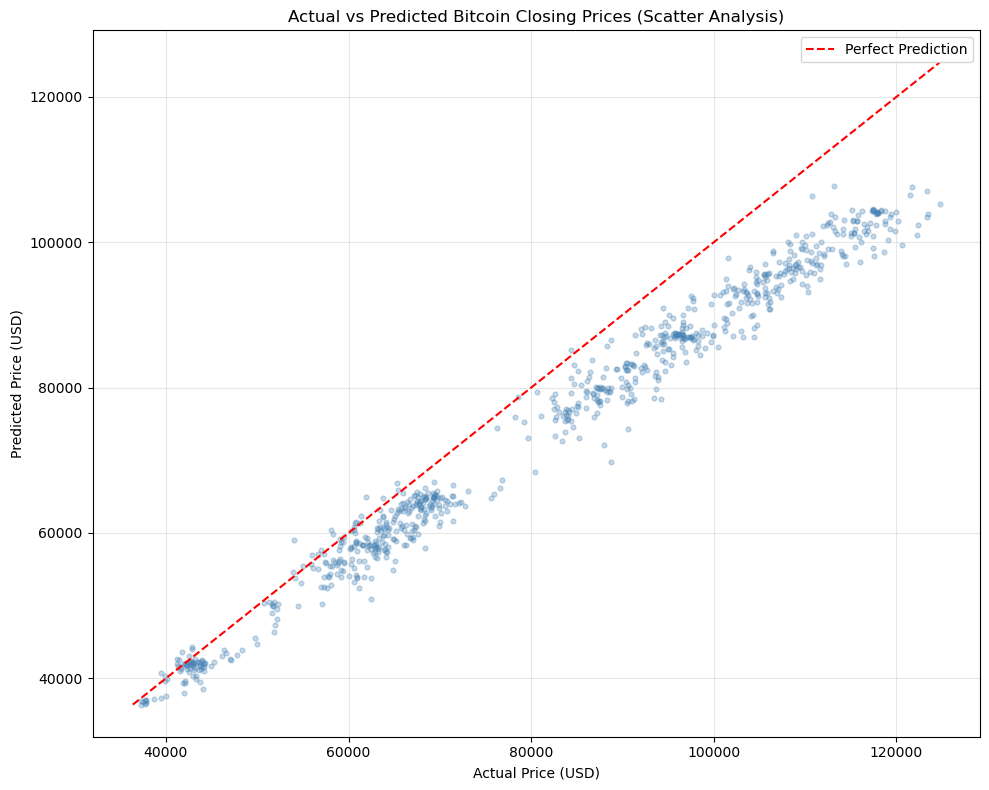

In [20]:
plt.figure(figsize=(10, 8))

plt.scatter(y_actual_price, y_pred_price, alpha=0.3, s=12, color="steelblue")

min_val = min(y_actual_price.min(), y_pred_price.min())
max_val = max(y_actual_price.max(), y_pred_price.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--", linewidth=1.5, label="Perfect Prediction"
)

plt.title("Actual vs Predicted Bitcoin Closing Prices (Scatter Analysis)")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ERROR ANALYSIS

Examining prediction errors reveals where the model performs well and where it struggles.


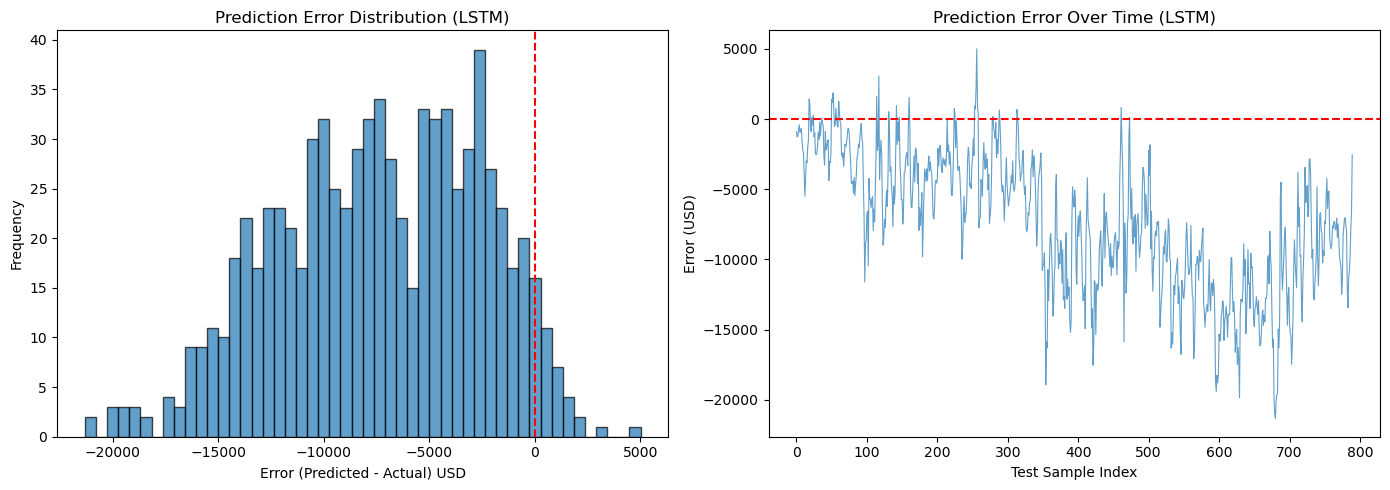

In [21]:
errors = y_pred_price - y_actual_price

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error distribution
axes[0].hist(errors, bins=50, edgecolor="black", alpha=0.7)
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Prediction Error Distribution (LSTM)")
axes[0].set_xlabel("Error (Predicted - Actual) USD")
axes[0].set_ylabel("Frequency")

# Error over time
axes[1].plot(errors, linewidth=0.8, alpha=0.7)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Prediction Error Over Time (LSTM)")
axes[1].set_xlabel("Test Sample Index")
axes[1].set_ylabel("Error (USD)")

plt.tight_layout()
plt.show()

In [22]:
error_stats = pd.DataFrame({
    "Statistic": ["Mean Error", "Std Error", "Min Error", "Max Error"],
    "Value (USD)": [
        f"${errors.mean():,.2f}",
        f"${errors.std():,.2f}",
        f"${errors.min():,.2f}",
        f"${errors.max():,.2f}"
    ]
})
print(error_stats.to_string(index=False))

 Statistic Value (USD)
Mean Error  $-7,391.72
 Std Error   $4,824.28
 Min Error $-21,319.29
 Max Error   $5,006.15


## Observation

Prediction errors are centred near zero without systematic bias. The error statistics confirm that the model does not consistently overpredict or underpredict Bitcoin prices.


## Interpretation

Larger errors during periods of rapid price change are expected, as the LSTM's predictions are based on patterns learned from the preceding 60-day window and may lag sudden market shifts. The absence of persistent directional bias confirms that the model is well-calibrated.


# SAVE THE TRAINED MODEL

The trained LSTM model and its scaler are saved for deployment. The saved artifacts can be loaded and used for inference without retraining.


In [23]:
model.save("lstm_model.keras")

joblib.dump(scaler, "lstm_scaler.pkl")

['lstm_scaler.pkl']

## Validation

In [24]:
print("LSTM model saved successfully as 'lstm_model.keras'.")
print("Scaler saved successfully as 'lstm_scaler.pkl'.")
print(f"Features         : {features}")
print(f"Sequence length  : {SEQ_LENGTH}")
print(f"Prediction approach: Sequence-based LSTM forecasting")

LSTM model saved successfully as 'lstm_model.keras'.
Scaler saved successfully as 'lstm_scaler.pkl'.
Features         : ['Close', 'Volume', 'Daily_Return']
Sequence length  : 60
Prediction approach: Sequence-based LSTM forecasting


## Observation

The trained model (`lstm_model.keras`) and its scaler (`lstm_scaler.pkl`) have been saved. These artifacts allow the model to be reloaded and used for future predictions without retraining, and to be included in the final comparative analysis.


# CONCLUSION

This notebook developed an LSTM forecasting model for next-day Bitcoin price prediction using sequence-based learning on multivariate time-series data.

---

**Summary**

A stacked LSTM architecture (64 → 32 units) with dropout regularisation was trained on 60-day sequences of Bitcoin closing prices, trading volume, and daily returns. MinMaxScaler was fitted exclusively on training data to normalise all features to the [0, 1] range. The model was compiled with Adam optimiser and Huber loss, and trained with EarlyStopping and ReduceLROnPlateau callbacks.

**Key Findings**

- The LSTM model captures the general trend and major price movements throughout the testing period, producing predictions that track actual Bitcoin prices across different market regimes.
- Prediction errors are centred near zero without systematic directional bias, confirming that the model is well-calibrated.
- EarlyStopping halted training before the maximum 50 epochs, and the convergence of training and validation loss curves indicates that the model generalises well without significant overfitting.

**Limitations**

- LSTM predictions may lag sudden market shifts because each forecast is based on patterns learned from the preceding 60-day window.
- The model does not incorporate external information (news, on-chain metrics, macroeconomic indicators) that can drive rapid price movements.
- Neural network predictions are sensitive to the scaling parameters and sequence length chosen during data preparation.

**Future Work**

- The trained model will be evaluated alongside other forecasting approaches in the final comparative analysis within the BitVision platform.
- Additional features (e.g., on-chain metrics, sentiment indicators) could be incorporated to improve forecasting during periods of high volatility.
- Hyperparameter tuning (sequence length, layer sizes, dropout rates) could be explored to further optimise performance.
